# Data analysis
## Import libraries and load dataset

In [1]:
import pandas as pd
from pandas import DataFrame        
import os
import re
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import emoji

# Check the cwd
os.getcwd()

'c:\\Users\\casaz\\Documents\\Simone\\University\\dhdk\\thesis\\evalita_task\\evalita2026-multipride-UniBO-FICLIT\\notebooks'

In [2]:
# Import data from CSV
data = pd.read_csv('../data/raw/train_it.csv')
data

,id,text,bio,label,lang
0,it_1231,La destra Italiana pur di non dire che loro od...,Il rispetto per il prossimo qualunque sia il s...,0,it
1,it_1713,"""Presupporre che tutti i bisessuali non sono m...",𝓕𝓲𝓵𝓵𝓮𝓭 𝔀𝓲𝓽𝓱 𝓯𝓾𝓻𝔂 𝓪𝓷𝓭 𝓼𝓽𝓪𝓻𝓻𝔂 𝓮𝔂𝓮𝓭,0,it
2,it_1474,"Se i diritti devono essere uguali, voglio che ...",User Experience Designer URL,0,it
3,it_58,che poi molti uomini trans subiscono lesbofobi...,"no matter where i go, you're there …",0,it
4,it_511,Che poi è l’etero medio come Pio e Amedeo che ...,T'appartengo ed io ci tengo \r\nE se prometto ...,0,it
...,...,...,...,...,...
1081,it_1340,Io mi sono rotto i coglioni di tutte queste po...,"Se incapaci di scherzare, se il resto del mond...",0,it
1082,it_595,"come una donna cis non può subire transfobia, ...",알잖아 널 가만히 둘 수 없는 걸,0,it
1083,it_844,Ehi comunità @USER questo giornalista di repub...,NaN,0,it
1084,it_1216,"@USER tom felton non è transfobico, ma ha anch...",NaN,0,it


## Basic stats

Check how many tweets are present in the data set, the distribution of the two classes and other general info.

In [3]:
# some basic stats
print(len(data))
print(data['label'].value_counts())
print(data.info())

1086
label
0    879
1    207
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1086 entries, 0 to 1085
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      1086 non-null   object
 1   text    1086 non-null   object
 2   bio     1000 non-null   object
 3   label   1086 non-null   int64 
 4   lang    1086 non-null   object
dtypes: int64(1), object(4)
memory usage: 42.5+ KB
None


The classes are pretty unbalanced: 807 tweets don't contain reclaimed slurs while 207 does.

Now we compute the average lenght of the tweets and the bios, to see if they'll fit the model constrains later.

In [4]:
# Print average length of texts in tokens
data['text_length'] = data['text'].apply(lambda x: len(x.split()))
print(data['text_length'].mean())

# Print average length of biographies in tokens (if available, otherwise do not count them)
data['bio_length'] = data['bio'].apply(lambda x: len(x.split()) if pd.notnull(x) else None)
print(data['bio_length'].mean())

34.06813996316759
13.302


## Lexical and Semantic Analysis

### Tokenization and Cleaning

Check for user mentions and url to see if they are useful to keep or not.

In [5]:
# Check for user mentions
data["user_mention"] = data["text"].apply(lambda x: re.findall(r"\s@\w+", x))

data[data["user_mention"].apply(lambda x: len(x) > 0)]

,id,text,bio,label,lang,text_length,bio_length,user_mention
6,it_1798,@USER @USER comunque la tua transfobia traspar...,"influenzer \r\npansexual, genderqueer and poly...",0,it,32,24.0,[ @USER]
17,it_1104,@USER @USER io ci vengo ai vostri raduni Gay P...,NaN,0,it,51,NaN,[ @USER]
18,it_1717,@USER @USER perché il femminismo si occupa di ...,piangente come i salici || radfem,0,it,40,6.0,[ @USER]
33,it_996,@USER @USER @USER “Frocio di merda” è omofobia...,NaN,0,it,30,NaN,"[ @USER, @USER]"
41,it_212,@USER @USER @USER Essere gay o trans non si in...,"Passionate about Queen, Star Trek, Apple, Culm...",0,it,51,20.0,"[ @USER, @USER]"
...,...,...,...,...,...,...,...,...
1037,it_1,@USER @USER @USER @USER @USER Basta già il vos...,Art. 52 della Costituzione: “La difesa della P...,0,it,32,14.0,"[ @USER, @USER, @USER, @USER]"
1051,it_280,@USER @USER @USER Esatto quindi la retorica di...,📈 DIGITAL RISK STRATEGIST enhancing #Digital #...,0,it,34,12.0,"[ @USER, @USER]"
1053,it_1173,@USER @USER Dopo la sfila dei trans e dei LGBT...,#̷̧̢̼̤͈̼̫̋̾Q̸̼͔͕̗͚̟̉̄̄͝a̷̞̗̺̐̔̚ṇ̶̨̢̦͚͚̜͇̯̉̓̑̉̏...,0,it,46,2.0,[ @USER]
1059,it_1381,@USER @USER E xenocomunista frocialista oltran...,Ho varcato le sogne del male e ho osato dire c...,1,it,7,24.0,[ @USER]


In [6]:
# Check for urls
data["urls"] = data["text"].apply(lambda x: re.findall(r"url", x))
data[data["urls"].apply(lambda x: len(x) > 0)]

,id,text,bio,label,lang,text_length,bio_length,user_mention,urls
205,it_103,Hanno picchiato un ragazzo di 12 anni urlandog...,All my life I wanted to look like Elizabeth Ta...,0,it,36,16.0,[],[url]
373,it_340,tw // omofobia\r\n.\r\n.\r\n.\r\n.\r\n.\r\n.\r...,⠀⠀⌗. . .vminkook 사랑 봇!!·˚ ༘𖡼.,0,it,34,6.0,[],[url]
475,it_3,Bello constatare come nel giorno del #Pride202...,"Divoratore di libri, pet lover, antifascista e...",0,it,27,22.0,[],[url]
593,it_1410,chi pensa che il problema sia l'omofobia è IL ...,Contro l'entropia culturale. Non sapevo di com...,1,it,49,10.0,[],[url]
620,it_21,"Che branco di guardoni morbosi, “fruga-mutande...","Amo il vento e le poesie di Pavese, sogno Itac...",1,it,42,23.0,[ @USER],[url]
646,it_938,I cis che urlano ala transfobia a destra e a m...,bi and RAD leaning | Portraits & illustrations...,0,it,35,11.0,[],[url]
688,it_19,se in un contesto normale non chiamate quei so...,🍂 ☕ 🍪\r\n ...,0,it,41,9.0,[],[url]
699,it_772,Della bionda urlatrice che veste i panni della...,"Quotidiano nazionale di Politica, Cultura & Op...",0,it,21,12.0,[],[url]
841,it_335,sto ridendo molto per chi urla alla transfobia...,"(he/they) rivoluzione, birra al limone",0,it,48,5.0,[],[url]
868,it_270,gente che letteralmente dice che le persone tr...,"t as in troy? no gabriella, t as in Time to de...",0,it,25,20.0,[],[url]


In [7]:
# Check for hashtags
data["hashtags"] = data["text"].apply(lambda x: re.findall(r"#\w+", x))
data[data["hashtags"].apply(lambda x: len(x) > 0)]

,id,text,bio,label,lang,text_length,bio_length,user_mention,urls,hashtags
0,it_1231,La destra Italiana pur di non dire che loro od...,Il rispetto per il prossimo qualunque sia il s...,0,it,37,20.0,[],[],"[#DDLZan, #Salvini, #omnibusla7]"
2,it_1474,"Se i diritti devono essere uguali, voglio che ...",User Experience Designer URL,0,it,38,4.0,[],[],"[#Libertà, #DDLZan]"
4,it_511,Che poi è l’etero medio come Pio e Amedeo che ...,T'appartengo ed io ci tengo \r\nE se prometto ...,0,it,26,19.0,[],[],"[#pioeamedeo, #LGBTQ, #DDLZan, #DDLZanLeggeCon..."
19,it_640,Qui Selvaggia Lucarelli dà della trans a una r...,3 ellle,0,it,20,2.0,[],[],[#Omofobia]
29,it_1020,"""i forci devono smetterla di farti domande sul...",august slipped away into a moment in time🌾 (he...,1,it,27,9.0,[],[],[#tellonym]
...,...,...,...,...,...,...,...,...,...,...
1036,it_1469,@USER attendo rivolta del mondo #lgbt perchè n...,1992 Industrial chemist. 1997 EEC certified En...,0,it,25,20.0,[],[],[#lgbt]
1038,it_1018,Nel frattempo però nella comunità LGBT c'è gen...,NaN,0,it,29,NaN,[],[],[#GFVIP]
1039,it_528,le persone omosessuali e trans hanno gli stess...,none of my axiom is like it should be\r\nex ma...,0,it,36,25.0,[],[],[#ddlzan]
1074,it_414,#omotransfobia O misoginia? Alzi la mano chi n...,"giornalista, fotografa, Asperger, due romanzi ...",0,it,53,22.0,[],[],[#omotransfobia]


In [8]:
# Check for emojis

data["emojis"] = data["text"].apply(lambda x: emoji.distinct_emoji_list(x))

data[data["emojis"].apply(lambda x: len(x) > 0)]

,id,text,bio,label,lang,text_length,bio_length,user_mention,urls,hashtags,emojis
7,it_665,⚫️ MA LA VIOLENZA CONTRO I GAY E I TRANS PROPR...,Studioso d’arte e musicofilo. Naturalista e Am...,0,it,46,20.0,[],[],[],"[👎🏿, ⚫]"
12,it_1753,tw: transfobia\r\n\r\nquando dite che il femmi...,23 - she/her - respect Giacomo Leopardi or die...,0,it,43,12.0,[],[],[],[™️]
14,it_1443,E con la Trans flag ho concluso momentaneament...,»Your Local Wish Shop ✨\r\n»Commissions Open🌙\...,0,it,42,16.0,[],[],[],"[💕, 😔]"
20,it_625,girl siamo seri? la transofobia non si giustif...,sparkling strangeness✨| rest in power chichi🖤 ...,0,it,44,8.0,[],[],[],"[😉, 😪]"
28,it_1640,E comunque non sei lesbica sei pansessuale con...,di giorno guardo i video di crime e di notte p...,0,it,27,23.0,[],[],[],[💀]
...,...,...,...,...,...,...,...,...,...,...,...
1044,it_71,effettuando pulizia contatti di forci tossici ...,"19 | he/she/they | “go fuck your prototype, i'...",1,it,21,15.0,[],[],[],[💋]
1047,it_1411,@USER tw // transfobia \r\n*spoiler* è perchè ...,-ˏˋ天使 ˊˎ-\r\nshe/ her ; ♓,0,it,25,6.0,[],[],[],"[🤮, 😖, 🤢]"
1055,it_832,Le donne trans subiscono transfobia e misogini...,Weird/Punk/feminist/Out of Control/Scrivo per ...,0,it,33,16.0,[],[],[],[✌🏽]
1064,it_231,@USER non è vero 😭 prima di tutto non tuttx tr...,cishet neurotypical able-bodied white man,0,it,46,5.0,[],[],[],[😭]


Urls have been replaced with the string "url". Since all user mentions are hidden for privacy, we can remove them without losing meaning.

The next function processes the text by removing user mentions, extra space, and useless punctuation. The texts are also transformed in lower-case for further analysis.

In [9]:
# Function to clean the tweets
def clean_text(text: str) -> str:
    """
    Cleans the input text by performing the following operations:
    - Removes user mentions (e.g., @username).
    - Removes urls.
    - Removes extra spaces and trims the text.
    - Converts the text to lowercase.

    Args:
        text (str): The input text to be cleaned.

    Returns:
        str: The cleaned text.
    """
    # Remove user mentions
    text = re.sub(r"@\w+", "", text)

    # Remove url
    text = re.sub(r"\burl\b", "", text, flags=re.I)
    
    # Remove useless extra space
    text = re.sub(r"\s+", " ", text).strip()

    # Transform everything in lower_case
    text_clean = text.lower()

    return text_clean

In [10]:
# Drop useless columns
data = data.drop(columns=["text_length", "bio_length", "user_mention", "urls"])

In [11]:
data["text_clean"] = data["text"].apply(lambda x: clean_text(x))

In [12]:
data

,id,text,bio,label,lang,hashtags,emojis,text_clean
0,it_1231,La destra Italiana pur di non dire che loro od...,Il rispetto per il prossimo qualunque sia il s...,0,it,"[#DDLZan, #Salvini, #omnibusla7]",[],la destra italiana pur di non dire che loro od...
1,it_1713,"""Presupporre che tutti i bisessuali non sono m...",𝓕𝓲𝓵𝓵𝓮𝓭 𝔀𝓲𝓽𝓱 𝓯𝓾𝓻𝔂 𝓪𝓷𝓭 𝓼𝓽𝓪𝓻𝓻𝔂 𝓮𝔂𝓮𝓭,0,it,[],[],"""presupporre che tutti i bisessuali non sono m..."
2,it_1474,"Se i diritti devono essere uguali, voglio che ...",User Experience Designer URL,0,it,"[#Libertà, #DDLZan]",[],"se i diritti devono essere uguali, voglio che ..."
3,it_58,che poi molti uomini trans subiscono lesbofobi...,"no matter where i go, you're there …",0,it,[],[],che poi molti uomini trans subiscono lesbofobi...
4,it_511,Che poi è l’etero medio come Pio e Amedeo che ...,T'appartengo ed io ci tengo \r\nE se prometto ...,0,it,"[#pioeamedeo, #LGBTQ, #DDLZan, #DDLZanLeggeCon...",[],che poi è l’etero medio come pio e amedeo che ...
...,...,...,...,...,...,...,...,...
1081,it_1340,Io mi sono rotto i coglioni di tutte queste po...,"Se incapaci di scherzare, se il resto del mond...",0,it,[],[],io mi sono rotto i coglioni di tutte queste po...
1082,it_595,"come una donna cis non può subire transfobia, ...",알잖아 널 가만히 둘 수 없는 걸,0,it,[],[],"come una donna cis non può subire transfobia, ..."
1083,it_844,Ehi comunità @USER questo giornalista di repub...,NaN,0,it,[],[],ehi comunità questo giornalista di repubblica ...
1084,it_1216,"@USER tom felton non è transfobico, ma ha anch...",NaN,0,it,[],[],"tom felton non è transfobico, ma ha anche dife..."


### Frequency Analysis

Now we want to perform frequency analyis. Specifically, we want to find the most frequent words for each class. To do so, we need to tokenize the tweets first. We'll use Spacy.

In [13]:
import spacy
nlp = spacy.load("it_core_news_sm")
import it_core_news_sm
nlp = it_core_news_sm.load()

In [14]:
def str_freq_analysis(data: DataFrame, column_name) -> Counter:
    """
    Performs frequency analysis on the text data in the specified column.

    This function tokenizes the text data using the spaCy NLP pipeline and counts the frequency 
    of words, excluding punctuation and specific parts of speech such as determiners, adpositions, 
    pronouns, auxiliaries, conjunctions, particles, and punctuation.

    Args:
        data (DataFrame): A pandas DataFrame containing the text data.
        column_name (str): The name of the column in the DataFrame containing the text to analyze.

    Returns:
        Counter: A Counter object containing the frequency of words in the specified text column.
    """
    freqs = Counter()

    for doc in nlp.pipe(data[column_name], batch_size=50):
        freqs.update([token.text.lower() for token in doc if not token.is_punct and token.pos_ not in {"DET", "ADP", "PRON", "AUX", "CCONJ", "SCONJ", "PART", "PUNCT"}])
    
    return freqs

In [15]:
def list_freq_analysis(data: DataFrame, column_name: str) -> Counter:
    """
    Performs frequency analysis on a column containing lists of items.

    Args:
        data (DataFrame): A pandas DataFrame containing the data.
        column_name (str): The name of the column containing lists of items.

    Returns:
        Counter: A Counter object with the frequency of each item in the lists.
    """
    freqs = Counter()
    
    # Ensure the column exists
    if column_name not in data.columns:
        raise ValueError(f"Column '{column_name}' does not exist in the DataFrame.")
    
    # Iterate through the column and update the counter
    for items in data[column_name]:
        if isinstance(items, list):  # Ensure the value is a list
            freqs.update(items)
    
    return freqs


In [24]:
def plot_common(ax, freqs: Counter, n_common: int=10) -> None:
    """
    Plots a horizontal bar chart to visualize the most common items or hashtags or emojis and their relative frequencies.

    Args:
        ax (matplotlib.axes.Axes): The axes object to plot the bar chart on.
        freqs (Counter): A Counter object containing item frequencies.
        n_common (int, optional): The number of most common items to display. Defaults to 10.

    Returns:
        None
    """
    common_items = freqs.most_common(n_common)

    items = []
    rel_frequencies = []
    total_items = freqs.total() 

    for word, frequency in common_items:
        items.append(word)
        rel_frequencies.append(frequency / total_items)

    y_pos = np.arange(len(items))


    ax.barh(y_pos, rel_frequencies, color="skyblue")
    ax.set_yticks(y_pos, labels=items)
    ax.invert_yaxis()
    ax.set_xlabel("Relative frequency")

In [17]:
data_reclamation = data[data["label"] == 1]
data_no_rec = data[data["label"] == 0]

In [18]:
freqs_hashtags = list_freq_analysis(data, "hashtags")

print(freqs_hashtags.most_common(20))

[('#omofobia', 14), ('#DDLZan', 13), ('#LGBT', 13), ('#ddlzan', 8), ('#Pride', 8), ('#LGBTQ', 7), ('#lgbt', 6), ('#PrideMonth', 6), ('#omotransfobia', 5), ('#pride', 5), ('#DDLZanLeggeControOmofobia', 4), ('#Zan', 4), ('#PRIDE2020', 4), ('#gay', 4), ('#ddlZan', 4), ('#GFVIP', 4), ('#noddlzan', 3), ('#Fedez', 3), ('#transgender', 3), ('#pioeamedeo', 2)]


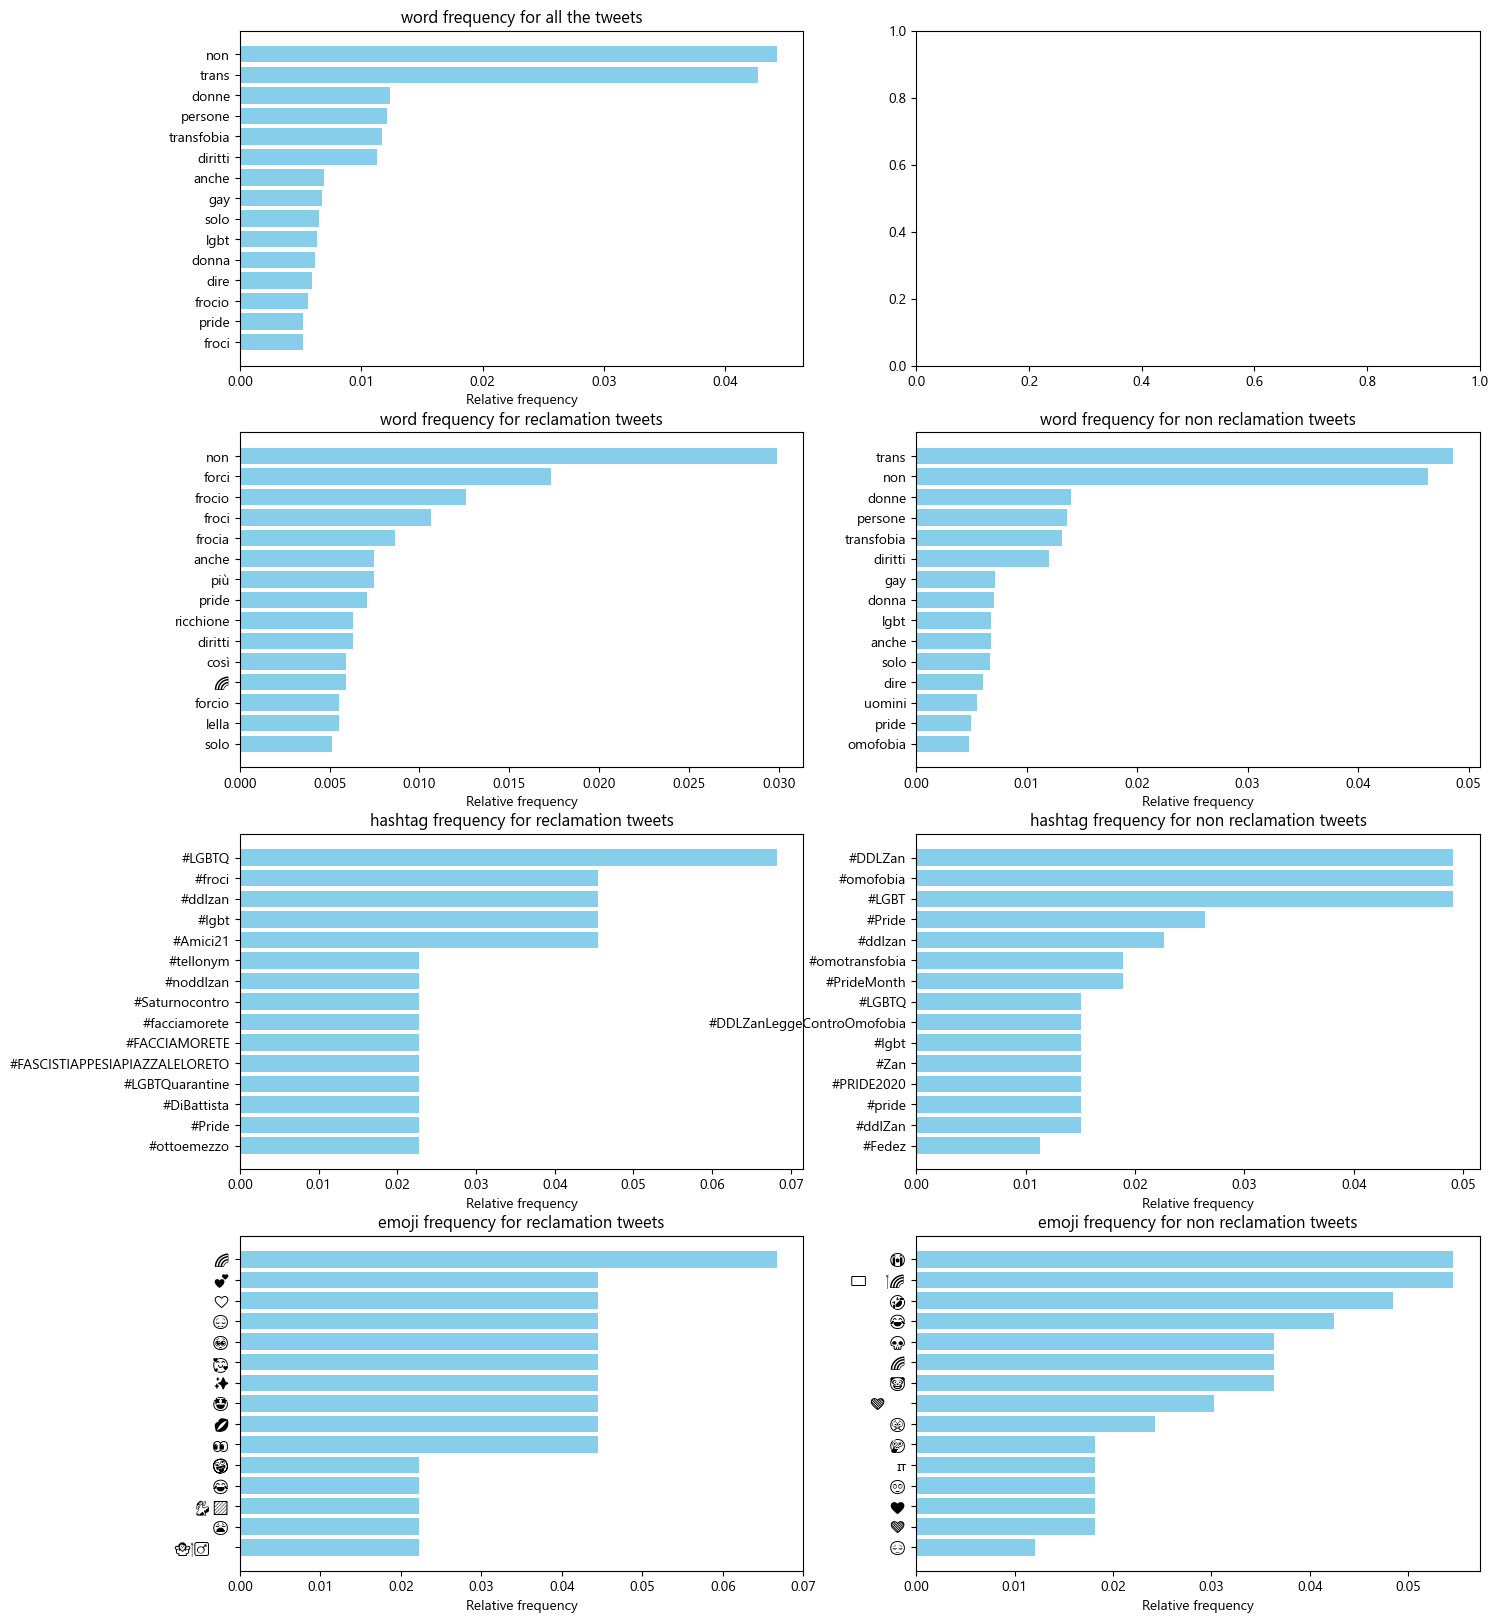

In [26]:
plt.rcParams["font.family"] = "Segoe UI Emoji"

fig, axs = plt.subplots(4, 2, figsize=(16, 20))

freqs_all = str_freq_analysis(data, "text_clean")
freqs_rec = str_freq_analysis(data_reclamation, "text_clean")
freqs_no_rec = str_freq_analysis(data_no_rec, "text_clean")
freqs_hashtags_rec = list_freq_analysis(data_reclamation, "hashtags")
freqs_hashtags_no_rec = list_freq_analysis(data_no_rec, "hashtags")
freqs_emojis_rec = list_freq_analysis(data_reclamation, "emojis")
freqs_emojis_no_rec = list_freq_analysis(data_no_rec, "emojis")

plot_common(axs[0, 0], freqs_all, 15)
plot_common(axs[1, 0], freqs_rec, 15)
plot_common(axs[1, 1], freqs_no_rec, 15)
plot_common(axs[2, 0], freqs_hashtags_rec, 15)
plot_common(axs[2, 1], freqs_hashtags_no_rec, 15)
plot_common(axs[3, 0], freqs_emojis_rec, 15)
plot_common(axs[3, 1], freqs_emojis_no_rec, 15)

axs[0, 0].set_title("word frequency for all the tweets")
axs[1, 0].set_title("word frequency for reclamation tweets")
axs[1, 1].set_title("word frequency for non reclamation tweets")
axs[2, 0].set_title("hashtag frequency for reclamation tweets")
axs[2, 1].set_title("hashtag frequency for non reclamation tweets")
axs[3, 0].set_title("emoji frequency for reclamation tweets")
axs[3, 1].set_title("emoji frequency for non reclamation tweets")

plt.show()

The plots give us some insights:
- In the most frequent words of the non-reclamation tweets, there are no slurs. The words *gay* and *trans* can sometimes be used as slurs, but they usually have a neutral meaning.
- In the reclamation tweets, different variations of *frocio* (e.g., frocio, forcio, forci, froci, frocia) are among the most frequent words. Some of these are misspelled, which could pose challenges during the model's training phase.
- Words that suggest reclamation, such as *pride*, are not particularly informative in distinguishing the label of the tweet.

### Characteristic Term Analysis

In [ ]:
# Import hurtlex data from TSV
hurtlex = pd.read_csv('../data/ras/hurtlex_IT.tsv', sep='\t')
                                                                        
hurtlex.head()

In [ ]:
homophobic_terms = hurtlex[hurtlex['category'] == "om"]

homophobic_terms

In [ ]:
# create a set of homophobic terms for faster lookup
homophobic_set = set(homophobic_terms['lemma'].str.lower())

# add also feminine forms (simple heuristic: add 'a' at the end if it ends with 'o')
homophobic_set.update({term[:-1] + 'a' for term in homophobic_set if term.endswith('o')})

print(len(homophobic_set))

In [ ]:
# Check for homophobic terms in the tweets end return a column with the terms found
def contains_homophobic_term(text):
    words = text.lower().split()
    for word in words:
        if word in homophobic_set:
            return word
    return None
data['contains_homophobic'] = data['text'].apply(contains_homophobic_term)
data[['text', 'contains_homophobic']]


In [ ]:
# Drop rows with None values in 'contains_homophobic' column
data_with_homophobic = data.dropna(subset=['contains_homophobic'])

data_with_homophobic[['text', 'contains_homophobic']]

In [ ]:
data_with_homophobic[data_with_homophobic['contains_homophobic'] == 'queer'][['text', 'contains_homophobic', 'label']]